# Driver concordance: R vs S

Needs in the same folder: `driver_concordance.py`, `driver_panel.tsv` (coordinates filled), `clairsto_all.pkl`.

Export `clairsto_all.pkl` from the Mac notebook first:
```python
clairsto_all.to_pickle("clairsto_all.pkl")
```

In [1]:
import glob
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from driver_concordance import SonopetMethods

In [2]:
import importlib
import driver_concordance  

importlib.reload(driver_concordance)

# re-import classes
from driver_concordance import SonopetMethods

In [3]:
# ---- config ----
VARIANTS = "clairsto_all.pkl"
PANEL    = "driver_panel.tsv"
BAM_GLOB = "/path/to/bam_files/ONTWGS9-*.bam"
CNS_GLOB = "/path/to/cnvkit/*/ONTWGS9-*.cns"
OUT_DIR  = "driver_concordance_out"

SEQID_TO_SR = {
    1:  "1S",  2:  "1R",
    3:  "2S",            # patient 2 – no resection, skip pairing
    4:  "3R",  5:  "3S",
    6:  "4R",  7:  "4S",
    8:  "5R",  9:  "5S",
    10: "6R",  11: "6S",
    12: "7R",  13: "7S",
    14: "8R",  15: "8S",
}

PLOT_CFG = {"fontsize_title": 20, "fontsize_label": 15, "fontsize_tick": 15}
plt.rcParams["font.family"] = "monospace"

RS = dict(conditions=("R", "S"), cond_colors={"R": "#d6604d", "S": "#2166ac"},
          plot_cfg=PLOT_CFG)

os.makedirs(OUT_DIR, exist_ok=True)

def seqid(name):
    return int(re.search(r"ONTWGS9-(\d+)", os.path.basename(str(name))).group(1))

In [4]:
GENE_COORDS = {
    "NF2":      {"hg38": {"chr": "22", "start": 29_999_545,  "end": 30_094_589}},
    "TRAF7":    {"hg38": {"chr": "16", "start": 2_336_727,   "end": 2_361_202}},
    "KLF4":     {"hg38": {"chr": "9",  "start": 107_552_749, "end": 107_558_277}},
    "AKT1":     {"hg38": {"chr": "14", "start": 104_769_349, "end": 104_795_751}},
    "SMO":      {"hg38": {"chr": "7",  "start": 128_831_749, "end": 128_875_540}},
    "PIK3CA":   {"hg38": {"chr": "3",  "start": 179_148_114, "end": 179_240_085}},
    "POLR2A":   {"hg38": {"chr": "17", "start": 7_484_984,   "end": 7_531_800}},
    "TP53":     {"hg38": {"chr": "17", "start": 7_668_402,   "end": 7_687_538}},
    "TERT":     {"hg38": {"chr": "5",  "start": 1_253_167,   "end": 1_295_068}},
    "CDKN2A":   {"hg38": {"chr": "9",  "start": 21_967_752,  "end": 21_995_324}},
    "CDKN2B":   {"hg38": {"chr": "9",  "start": 22_002_903,  "end": 22_009_371}},
    "BAP1":     {"hg38": {"chr": "3",  "start": 52_401_923,  "end": 52_430_819}},
    "SMARCE1":  {"hg38": {"chr": "17", "start": 38_617_478,  "end": 38_640_750}},
    "SMARCB1":  {"hg38": {"chr": "22", "start": 23_786_752,  "end": 23_819_280}},
    "PTEN":     {"hg38": {"chr": "10", "start": 87_863_113,  "end": 87_971_930}},
    "EGFR":     {"hg38": {"chr": "7",  "start": 55_018_820,  "end": 55_211_628}},
}

In [5]:
clairsto_all = pd.read_pickle(VARIANTS)
clairsto_all["chrom"] = clairsto_all["chrom"].astype(str)
clairsto_all["pos"] = clairsto_all["pos"].astype(int)

groups = SonopetMethods.build_groups(clairsto_all["sample"].unique(), SEQID_TO_SR,
                                     parse_id=seqid, require=("R", "S"))
print(groups)

[INFO] P2: missing {'R'}, skipping.
{'P1': {'S': 'ONTWGS9-1-238701-NP01', 'R': 'ONTWGS9-2-238702-NP01'}, 'P3': {'R': 'ONTWGS9-4-240182-NP01', 'S': 'ONTWGS9-5-240183-NP01'}, 'P4': {'R': 'ONTWGS9-6-240184-NP01', 'S': 'ONTWGS9-7-240185-NP01'}, 'P5': {'R': 'ONTWGS9-8-240186-NP01', 'S': 'ONTWGS9-9-240187-NP01'}, 'P6': {'R': 'ONTWGS9-10-240188-NP01', 'S': 'ONTWGS9-11-240189-NP01'}, 'P7': {'R': 'ONTWGS9-12-240190-NP01', 'S': 'ONTWGS9-13-240191-NP01'}, 'P8': {'R': 'ONTWGS9-14-240192-NP01', 'S': 'ONTWGS9-15-240193-NP01'}}


In [6]:
GENES = list(GENE_COORDS)
BUILD = "hg38"

rows = [[g, g, GENE_COORDS[g][BUILD]["chr"],
         GENE_COORDS[g][BUILD]["start"], GENE_COORDS[g][BUILD]["end"], "gene"]
        for g in GENES]
rows += [["TERT C228T", "TERT", "5", 1295113, 1295113, "hotspot"],
         ["TERT C250T", "TERT", "5", 1295135, 1295135, "hotspot"]]

# variants use bare chromosome names; CNVkit output is chr-prefixed
panel = pd.DataFrame(rows, columns=["name", "gene", "chrom", "start", "end", "kind"])
panel["chrom"] = panel["chrom"].astype(str)
panel_cnv = panel.assign(chrom="chr" + panel["chrom"])
print(panel.to_string())

          name     gene chrom      start        end     kind
0          NF2      NF2    22   29999545   30094589     gene
1        TRAF7    TRAF7    16    2336727    2361202     gene
2         KLF4     KLF4     9  107552749  107558277     gene
3         AKT1     AKT1    14  104769349  104795751     gene
4          SMO      SMO     7  128831749  128875540     gene
5       PIK3CA   PIK3CA     3  179148114  179240085     gene
6       POLR2A   POLR2A    17    7484984    7531800     gene
7         TP53     TP53    17    7668402    7687538     gene
8         TERT     TERT     5    1253167    1295068     gene
9       CDKN2A   CDKN2A     9   21967752   21995324     gene
10      CDKN2B   CDKN2B     9   22002903   22009371     gene
11        BAP1     BAP1     3   52401923   52430819     gene
12     SMARCE1  SMARCE1    17   38617478   38640750     gene
13     SMARCB1  SMARCB1    22   23786752   23819280     gene
14        PTEN     PTEN    10   87863113   87971930     gene
15        EGFR     EGFR 

In [7]:
samples = {seqid(s): s for s in clairsto_all["sample"].unique()}
bam_by_sample = {samples[seqid(b)]: b
                 for b in sorted(glob.glob(BAM_GLOB)) if seqid(b) in samples}
cns_by_sample = {samples[seqid(f)]: pd.read_csv(f, sep="\t")
                 for f in sorted(glob.glob(CNS_GLOB))
                 if seqid(f) in samples and not f.endswith((".call.cns", ".bintest.cns"))}
print(f"BAMs: {len(bam_by_sample)}  CNS: {len(cns_by_sample)}  samples: {len(samples)}")
if cns_by_sample:
    print("cns chroms:", cns_by_sample[list(cns_by_sample)[0]]["chromosome"].unique()[:3])

BAMs: 15  CNS: 15  samples: 15
cns chroms: <ArrowStringArray>
['chr1', 'chr2', 'chr3']
Length: 3, dtype: str


In [8]:
hits = SonopetMethods._annotate_panel(clairsto_all, panel, flank=0)
print("panel hits:", len(hits))
if len(hits):
    print(hits.groupby(["gene", "filter"]).size())

panel hits: 103
gene     filter
AKT1     PASS       6
CDKN2A   PASS       3
EGFR     PASS      15
NF2      PASS       6
PIK3CA   PASS       5
POLR2A   PASS      12
PTEN     PASS       5
SMARCB1  PASS       9
SMARCE1  PASS      12
SMO      PASS      20
TERT     PASS       2
TP53     PASS       5
TRAF7    PASS       3
dtype: int64


In [9]:
drv_table, drv_summary = SonopetMethods.driver_concordance_table(
    clairsto_all, panel, groups, bam_by_sample, flank=0, min_alt=2, min_dp=10)
drv_table.to_csv(f"{OUT_DIR}/driver_concordance_table.tsv", sep="\t", index=False)
drv_summary.to_csv(f"{OUT_DIR}/driver_concordance_summary.tsv", sep="\t")
drv_summary

concordance,all_called,detected_not_called,missing,low_coverage,n_variants,concordance_rate
group,,,,,,
P1,4,4,0,0,8,1.000000
P3,1,5,1,0,7,0.857143
P4,15,4,0,0,19,1.000000
P5,5,1,0,0,6,1.000000
P6,2,5,0,0,7,1.000000
P7,1,2,1,0,4,0.750000
P8,7,5,1,0,13,0.923077


In [10]:
print("variant chroms:", clairsto_all["chrom"].unique()[:5])
print("panel chroms  :", panel["chrom"].unique()[:5])
print(clairsto_all["filter"].value_counts())
print("variants total:", len(clairsto_all))

hits = SonopetMethods._annotate_panel(clairsto_all, panel, flank=0)
print("panel hits (any filter):", len(hits))
if len(hits):
    print(hits.groupby(["gene", "filter"]).size())

variant chroms: <ArrowStringArray>
['1', '2', '3', '4', '5']
Length: 5, dtype: str
panel chroms  : <ArrowStringArray>
['22', '16', '9', '14', '7']
Length: 5, dtype: str
filter
PASS    300538
Name: count, dtype: int64
variants total: 300538
panel hits (any filter): 103
gene     filter
AKT1     PASS       6
CDKN2A   PASS       3
EGFR     PASS      15
NF2      PASS       6
PIK3CA   PASS       5
POLR2A   PASS      12
PTEN     PASS       5
SMARCB1  PASS       9
SMARCE1  PASS      12
SMO      PASS      20
TERT     PASS       2
TP53     PASS       5
TRAF7    PASS       3
dtype: int64


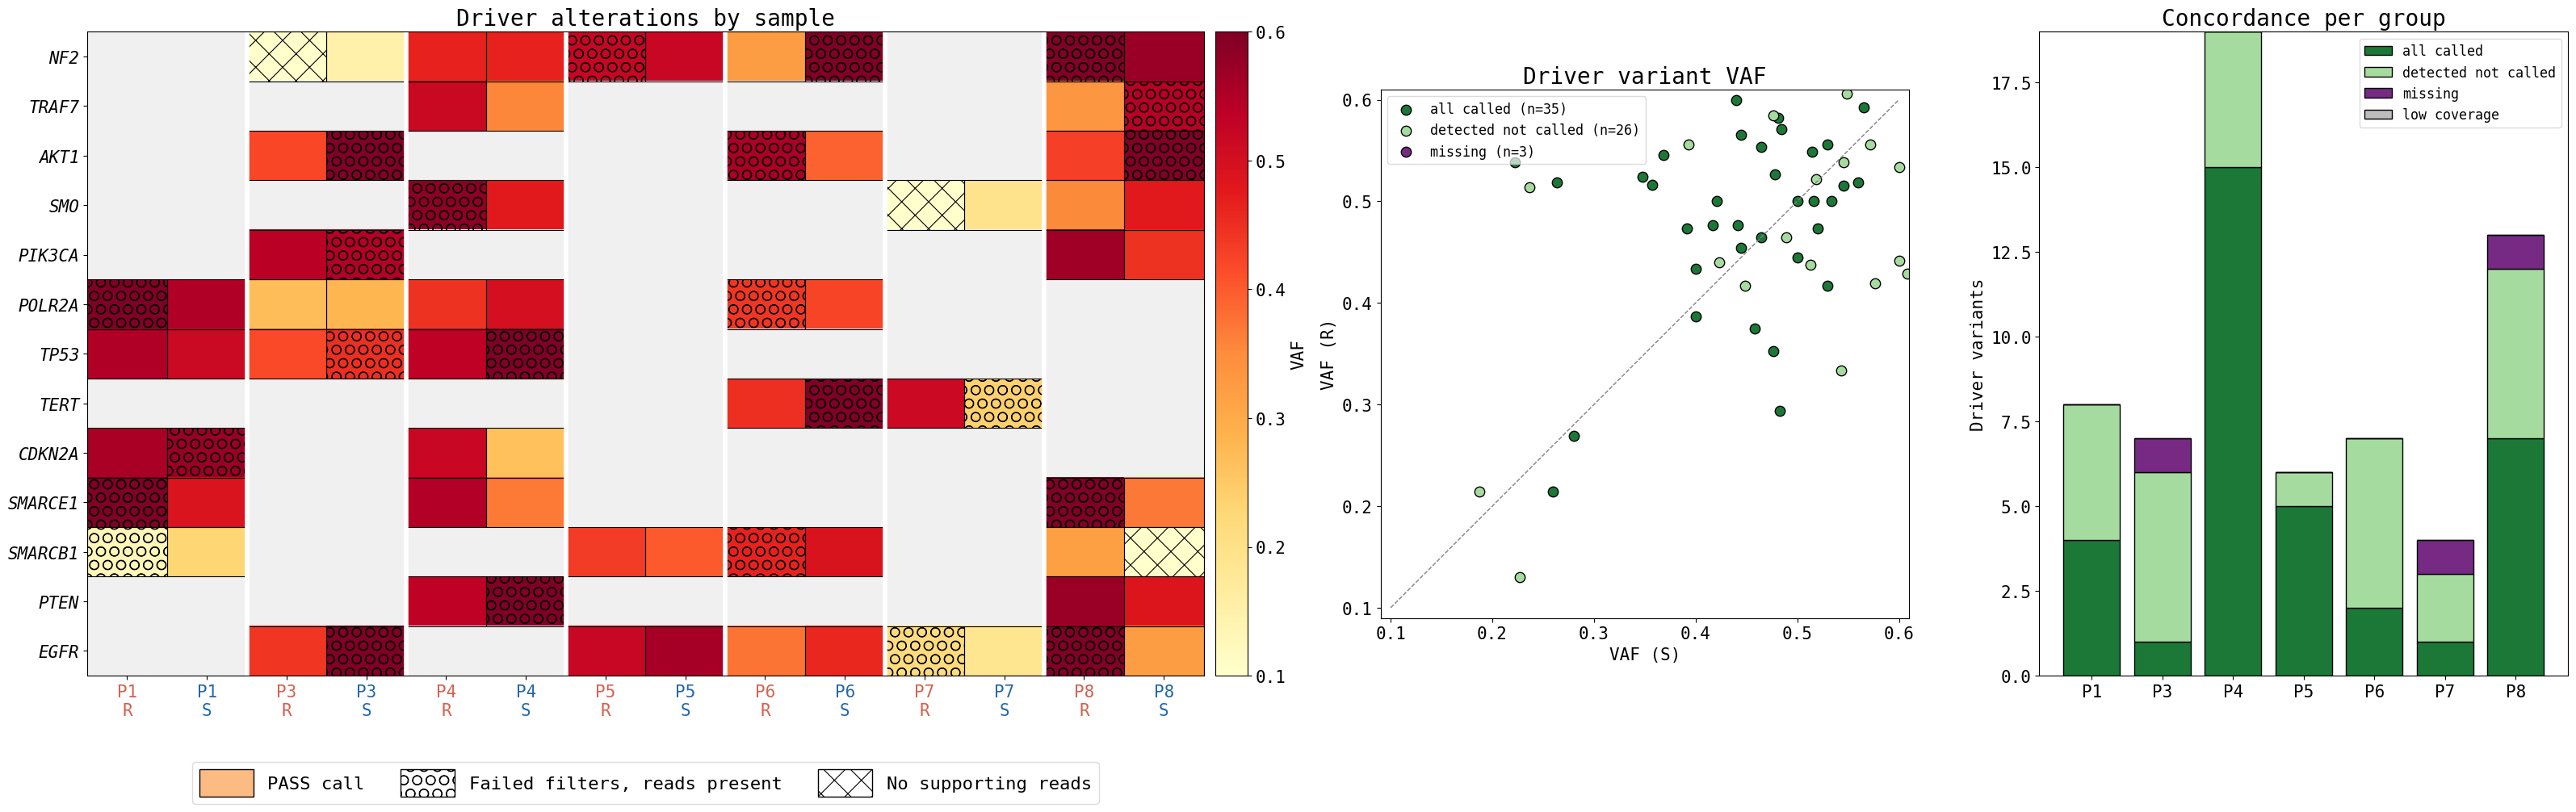

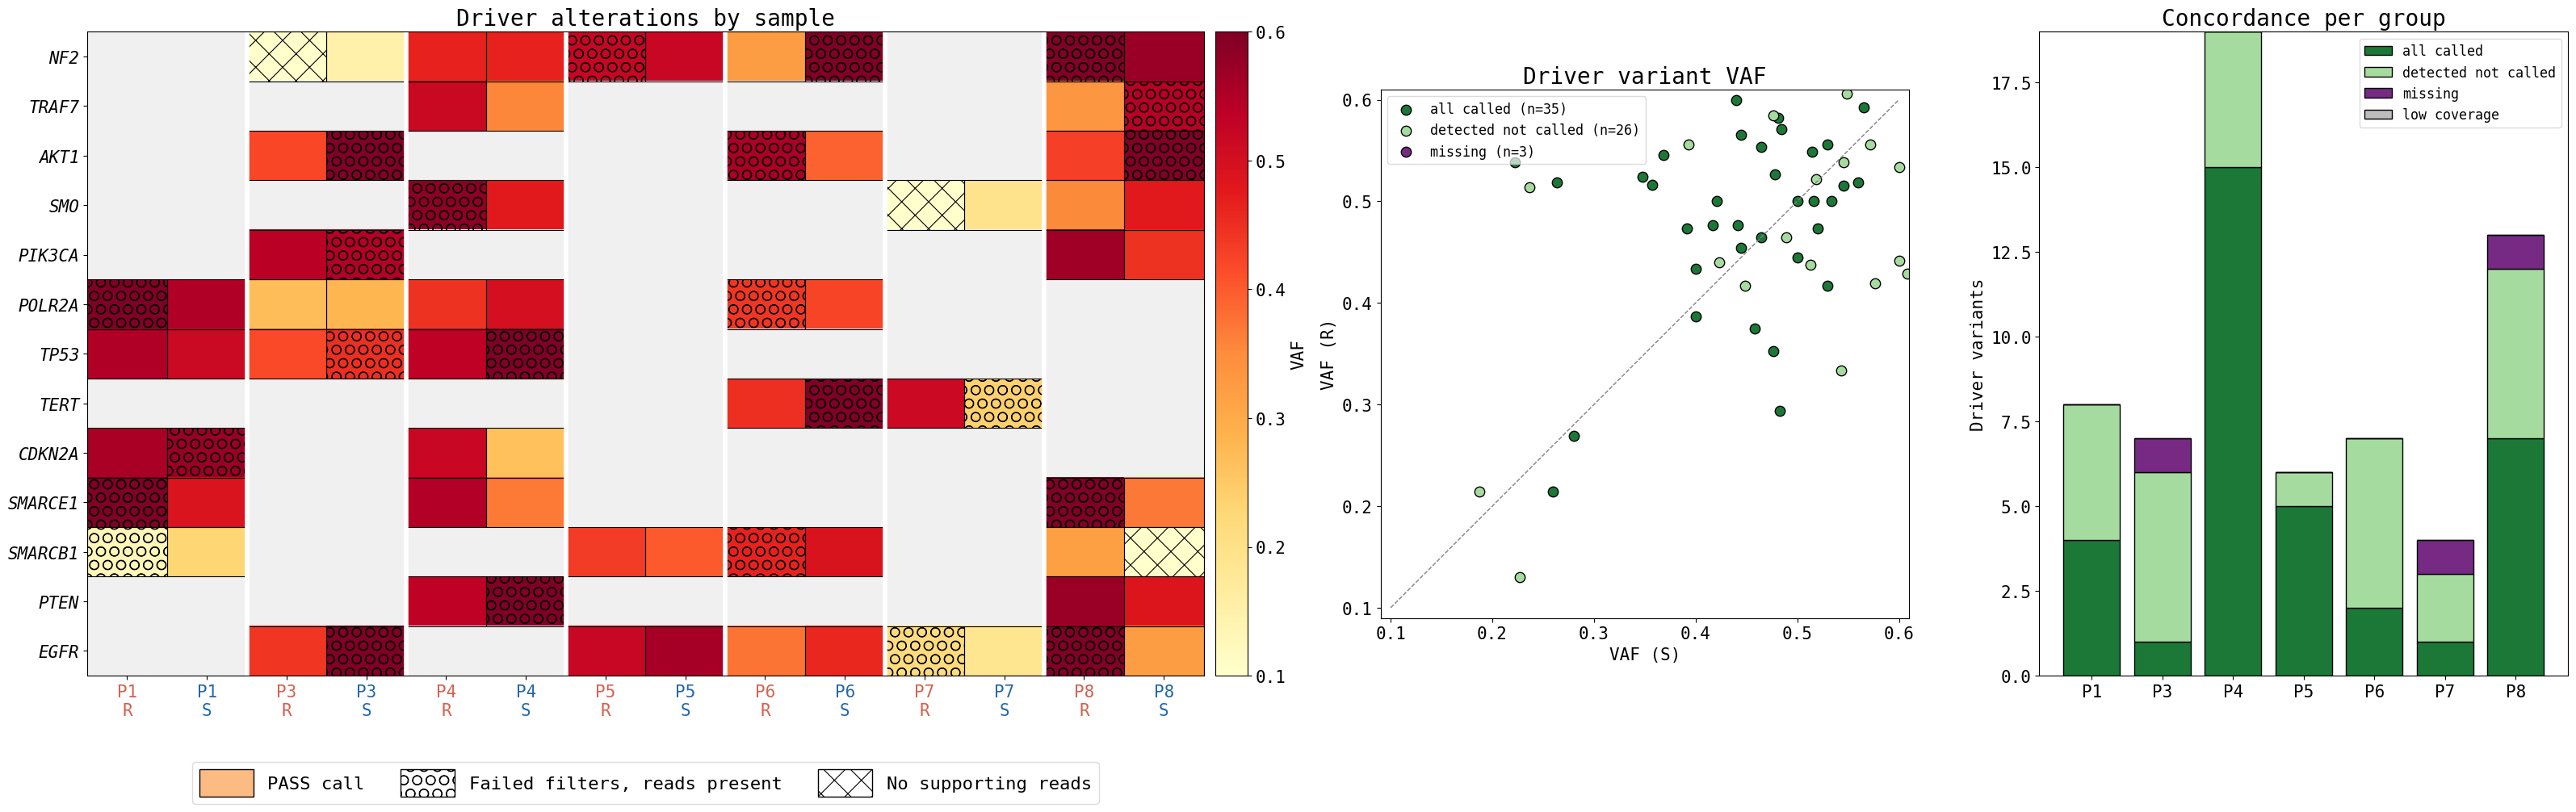

In [11]:
SonopetMethods.plot_driver_concordance(drv_table, drv_summary, panel, groups, xy=("S", "R"),
                                       vaf_range=(0.1, 0.6),
                                       save_path=f"{OUT_DIR}/driver_concordance", **RS)

In [12]:
for side in ("R", "S"):
    m = (drv_table[f"state_{side}"] == "detected") & (drv_table[f"fvaf_{side}"] > 0.6)
    drv_table.loc[m, f"state_{side}"] = "above_window"

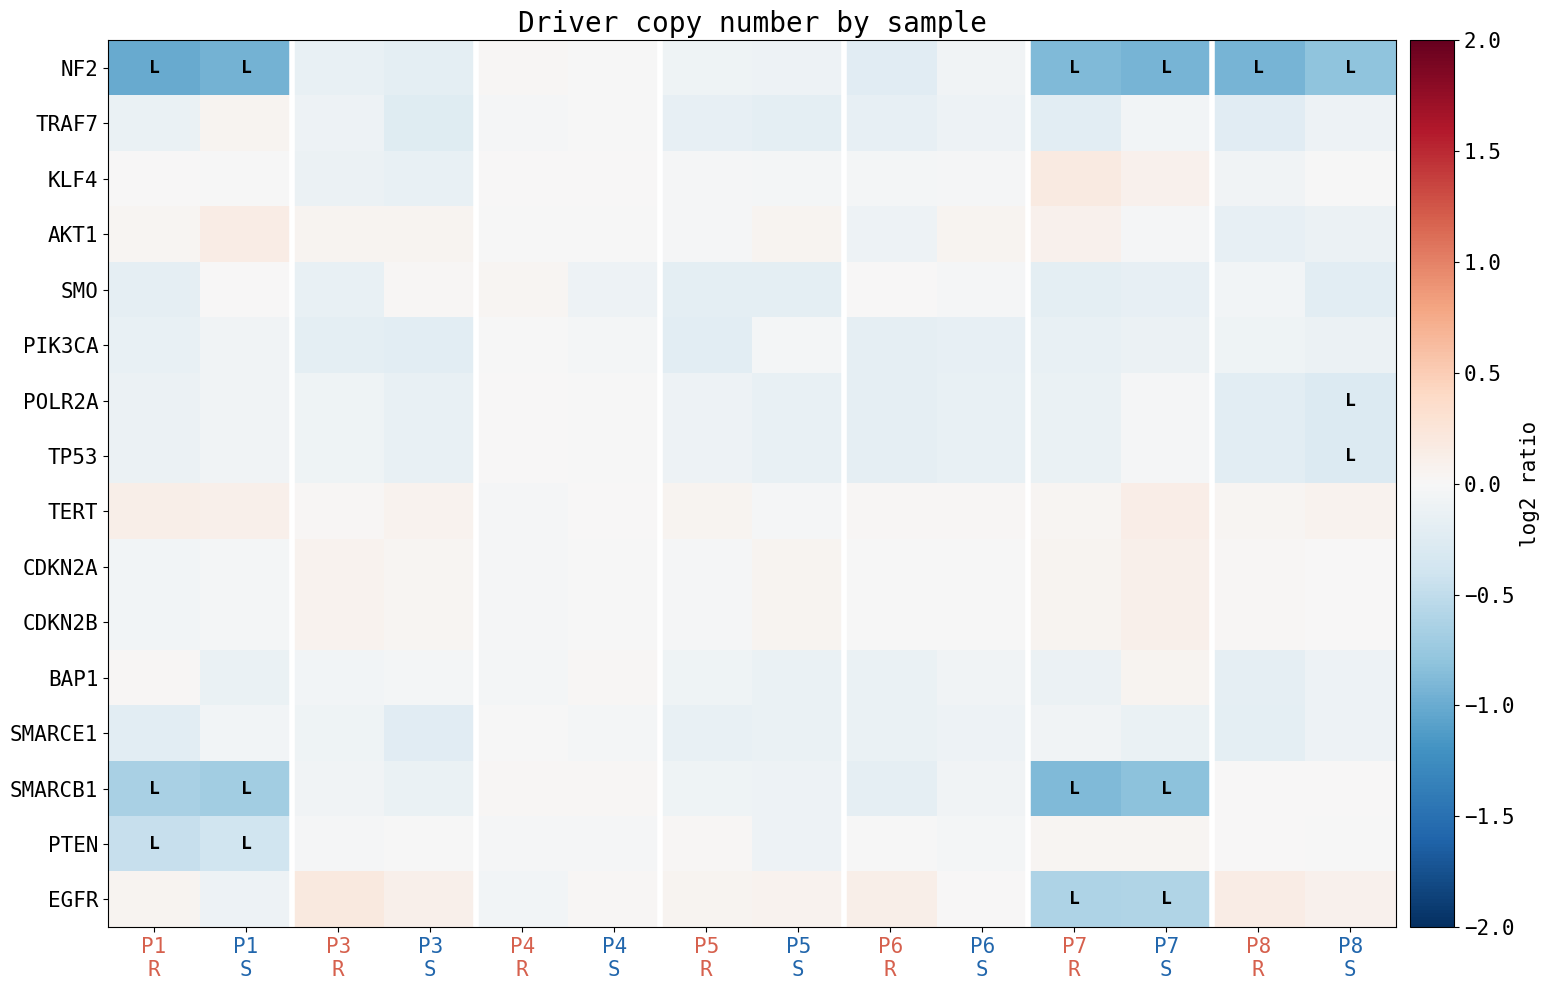

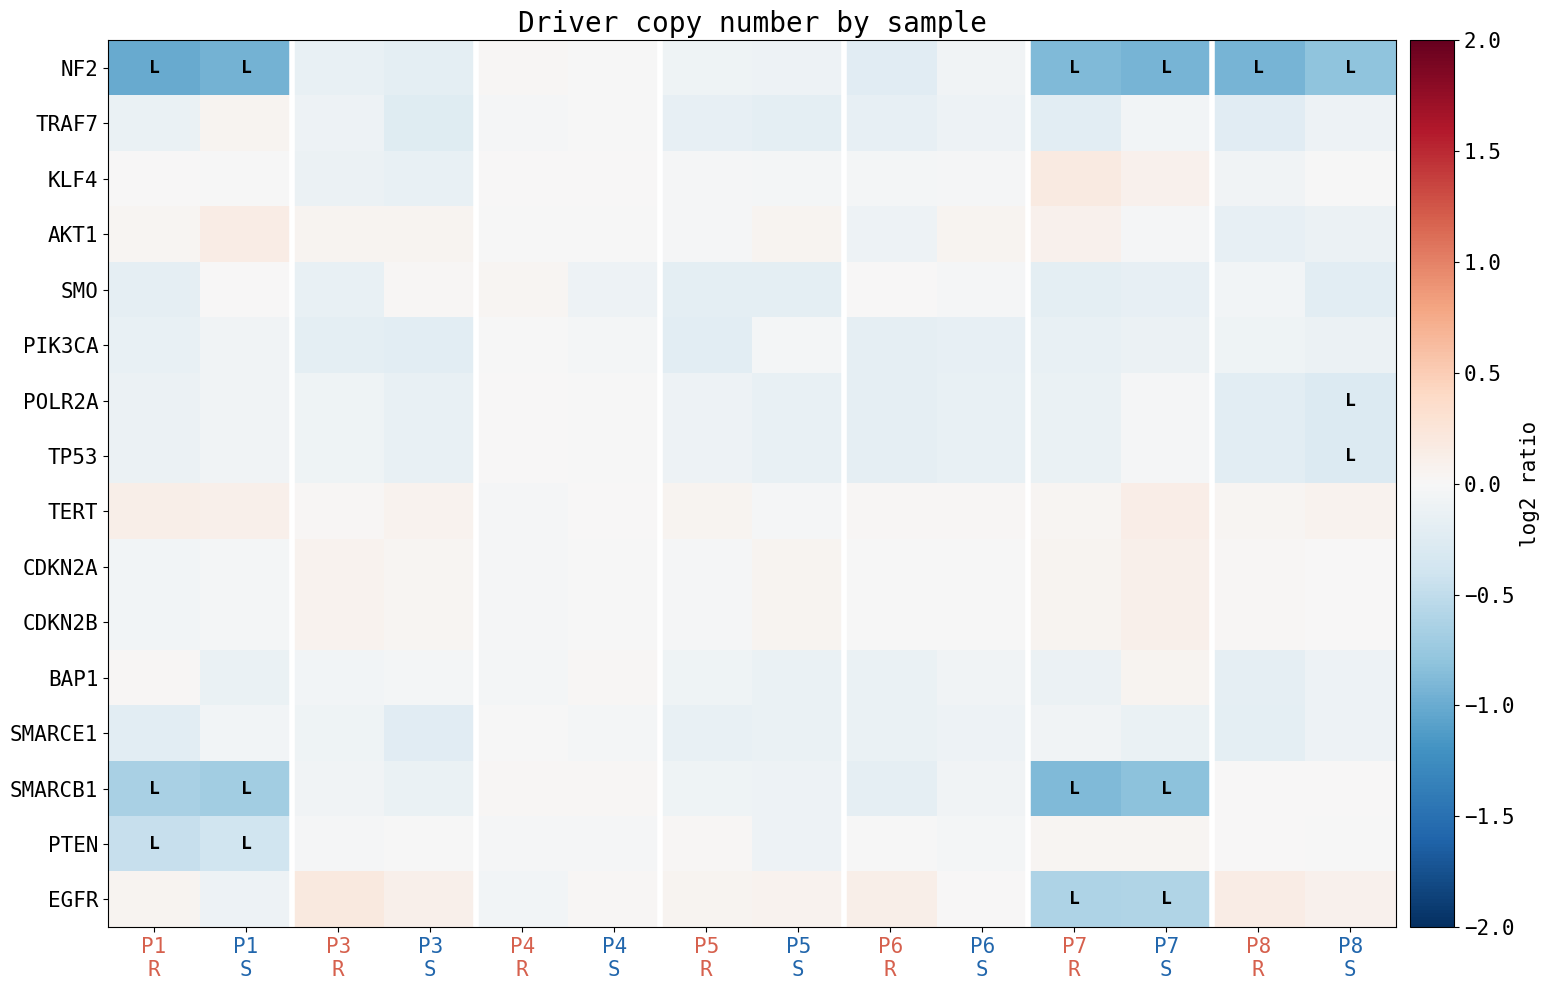

In [13]:
drv_cnv = SonopetMethods.driver_cnv_table(cns_by_sample, panel_cnv, groups)
drv_cnv.to_csv(f"{OUT_DIR}/driver_cnv_table.tsv", sep="\t", index=False)
SonopetMethods.plot_driver_cnv(drv_cnv, groups, save_path=f"{OUT_DIR}/driver_cnv", **RS)